# SVM Hyperparameter Grid Search — Update Report

This notebook visualizes the results of the SVM hyperparameter grid search conducted for the **update report**.

**HOG Parameters used:**
```python
HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(16, 16),
    cells_per_block=(2, 2),
)
```

**Best params:** `C=10.0, gamma='scale'` — Val Top-1: **0.0964**, Top-5: **0.2208**

# Raw output:

[1/16] Training SVM — C=0.1, gamma=0.0001...  
[1/16] Evaluating on val set...  
Val — Top-1: 0.0054, Top-5: 0.0227  
[1/16] C=0.1, gamma=0.0001 — Top-1: 0.0054, Top-5: 0.0227 <-- best so far  

[2/16] Training SVM — C=0.1, gamma=0.001...  
[2/16] Evaluating on val set...  
Val — Top-1: 0.0054, Top-5: 0.0227  
[2/16] C=0.1, gamma=0.001 — Top-1: 0.0054, Top-5: 0.0227  

[3/16] Training SVM — C=0.1, gamma=0.01...  
[3/16] Evaluating on val set...   
Val — Top-1: 0.0054, Top-5: 0.0231  
[3/16] C=0.1, gamma=0.01 — Top-1: 0.0054, Top-5: 0.0231  

[4/16] Training SVM — C=0.1, gamma=scale...  
[4/16] Evaluating on val set...  
Val — Top-1: 0.0054, Top-5: 0.0243  
[4/16] C=0.1, gamma=scale — Top-1: 0.0054, Top-5: 0.0243  

[5/16] Training SVM — C=1.0, gamma=0.0001...  
[5/16] Evaluating on val set...  
Val — Top-1: 0.0054, Top-5: 0.0227  
[5/16] C=1.0, gamma=0.0001 — Top-1: 0.0054, Top-5: 0.0227  

[6/16] Training SVM — C=1.0, gamma=0.001...  
[6/16] Evaluating on val set...  
Val — Top-1: 0.0054, Top-5: 0.0227  
[6/16] C=1.0, gamma=0.001 — Top-1: 0.0054, Top-5: 0.0227  

[7/16] Training SVM — C=1.0, gamma=0.01...  
[7/16] Evaluating on val set...  
Val — Top-1: 0.0222, Top-5: 0.0815  
[7/16] C=1.0, gamma=0.01 — Top-1: 0.0222, Top-5: 0.0815 <-- best so far  

[8/16] Training SVM — C=1.0, gamma=scale...  
[8/16] Evaluating on val set...  
Val — Top-1: 0.0700, Top-5: 0.1767  
[8/16] C=1.0, gamma=scale — Top-1: 0.0700, Top-5: 0.1767 <-- best so far  

[9/16] Training SVM — C=10.0, gamma=0.0001...  
[9/16] Evaluating on val set...  
Val — Top-1: 0.0054, Top-5: 0.0227  
[9/16] C=10.0, gamma=0.0001 — Top-1: 0.0054, Top-5: 0.0227  

[10/16] Training SVM — C=10.0, gamma=0.001...  
[10/16] Evaluating on val set...  
Val — Top-1: 0.0301, Top-5: 0.1133  
[10/16] C=10.0, gamma=0.001 — Top-1: 0.0301, Top-5: 0.1133  

[11/16] Training SVM — C=10.0, gamma=0.01...  
[11/16] Evaluating on val set...  
Val — Top-1: 0.0803, Top-5: 0.2059  
[11/16] C=10.0, gamma=0.01 — Top-1: 0.0803, Top-5: 0.2059 <-- best so far  

[12/16] Training SVM — C=10.0, gamma=scale...  
[12/16] Evaluating on val set...  
Val — Top-1: 0.0964, Top-5: 0.2208  
[12/16] C=10.0, gamma=scale — Top-1: 0.0964, Top-5: 0.2208 <-- best so far  

[13/16] Training SVM — C=100.0, gamma=0.0001...  
[13/16] Evaluating on val set...  
Val — Top-1: 0.0313, Top-5: 0.1137  
[13/16] C=100.0, gamma=0.0001 — Top-1: 0.0313, Top-5: 0.1137  

[14/16] Training SVM — C=100.0, gamma=0.001...  
[14/16] Evaluating on val set...  
Val — Top-1: 0.0700, Top-5: 0.1952  
[14/16] C=100.0, gamma=0.001 — Top-1: 0.0700, Top-5: 0.1952  

[15/16] Training SVM — C=100.0, gamma=0.01...  
[15/16] Evaluating on val set...  
Val — Top-1: 0.0766, Top-5: 0.2030  
[15/16] C=100.0, gamma=0.01 — Top-1: 0.0766, Top-5: 0.2030  

[16/16] Training SVM — C=100.0, gamma=scale...  
[16/16] Evaluating on val set...  
Val — Top-1: 0.0964, Top-5: 0.2208  
[16/16] C=100.0, gamma=scale — Top-1: 0.0964, Top-5: 0.2208  

Best params: {'C': 10.0, 'gamma': 'scale'} — Val Top-1: 0.0964.

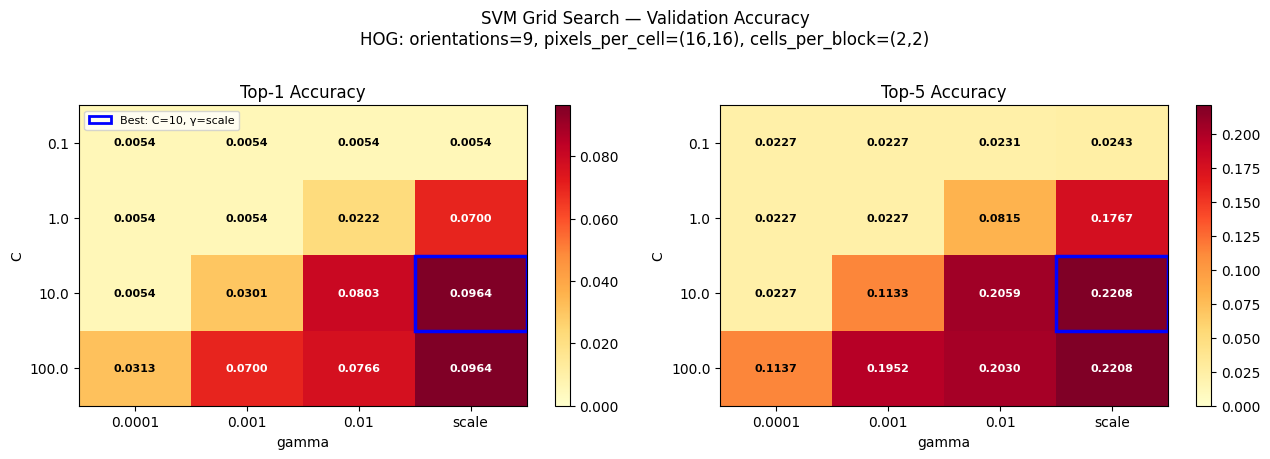

Best params: C=10.0, gamma='scale' — Val Top-1: 0.0964, Top-5: 0.2208


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# HOG_PARAMS = dict(
#     orientations=9,
#     pixels_per_cell=(16, 16),
#     cells_per_block=(2, 2),
# )

# Grid search results: (C, gamma, top1, top5)
results = [
    (0.1,   '0.0001', 0.0054, 0.0227),
    (0.1,   '0.001',  0.0054, 0.0227),
    (0.1,   '0.01',   0.0054, 0.0231),
    (0.1,   'scale',  0.0054, 0.0243),
    (1.0,   '0.0001', 0.0054, 0.0227),
    (1.0,   '0.001',  0.0054, 0.0227),
    (1.0,   '0.01',   0.0222, 0.0815),
    (1.0,   'scale',  0.0700, 0.1767),
    (10.0,  '0.0001', 0.0054, 0.0227),
    (10.0,  '0.001',  0.0301, 0.1133),
    (10.0,  '0.01',   0.0803, 0.2059),
    (10.0,  'scale',  0.0964, 0.2208),
    (100.0, '0.0001', 0.0313, 0.1137),
    (100.0, '0.001',  0.0700, 0.1952),
    (100.0, '0.01',   0.0766, 0.2030),
    (100.0, 'scale',  0.0964, 0.2208),
]

C_vals   = sorted(set(r[0] for r in results))
g_vals   = ['0.0001', '0.001', '0.01', 'scale']

top1_grid = np.zeros((len(C_vals), len(g_vals)))
top5_grid = np.zeros((len(C_vals), len(g_vals)))

for c, g, t1, t5 in results:
    i = C_vals.index(c)
    j = g_vals.index(g)
    top1_grid[i, j] = t1
    top5_grid[i, j] = t5

C_labels = [str(c) for c in C_vals]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(
    "SVM Grid Search — Validation Accuracy\n"
    r"HOG: orientations=9, pixels_per_cell=(16,16), cells_per_block=(2,2)",
    fontsize=12, y=1.01
)

for ax, grid, title in zip(axes, [top1_grid, top5_grid], ["Top-1 Accuracy", "Top-5 Accuracy"]):
    im = ax.imshow(grid, cmap="YlOrRd", aspect="auto", vmin=0)
    ax.set_xticks(range(len(g_vals)))
    ax.set_xticklabels(g_vals)
    ax.set_yticks(range(len(C_vals)))
    ax.set_yticklabels(C_labels)
    ax.set_xlabel("gamma")
    ax.set_ylabel("C")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, format=mticker.FormatStrFormatter("%.3f"))
    for i in range(len(C_vals)):
        for j in range(len(g_vals)):
            val = grid[i, j]
            color = "white" if val > grid.max() * 0.6 else "black"
            ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                    fontsize=8, color=color, fontweight="bold")

# Highlight best cell (C=10, gamma='scale') in both heatmaps
best_i, best_j = C_vals.index(10.0), g_vals.index('scale')
for ax in axes:
    ax.add_patch(plt.Rectangle(
        (best_j - 0.5, best_i - 0.5), 1, 1,
        fill=False, edgecolor="blue", linewidth=2.5, label="Best params"
    ))

axes[0].legend(handles=[
    plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor="blue", linewidth=2)
], labels=["Best: C=10, γ=scale"], loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig("svm_grid_search.png", dpi=150, bbox_inches="tight")
plt.show()
print("Best params: C=10.0, gamma='scale' — Val Top-1: 0.0964, Top-5: 0.2208")